In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. UČITAVANJE PODATAKA (koristi već očišćene, bez vikenda!)
# ============================================================
df = pd.read_csv("data/sve.csv", index_col="Date", parse_dates=True)
 
# ------------------------------------------------------------
# Sužavanje na kraći, relevantniji period (izbegava mešanje
# različitih monetarnih rezima - nulte kamate, krize, itd.)
# Sadrži: COVID krah (2020) i FED/ECB ciklus podizanja kamata (2022-23)

# ------------------------------------------------------------
df = df.loc["2022-01-01":"2024-08-07"]
df = df.resample("W-FRI").last() 

print(f"Period nakon secenja: {df.index.min()} do {df.index.max()}")
print(f"Broj opservacija: {len(df)}")
 
# Kamatni diferencijal - naš eksterni "feature" (H matrica će ga koristiti)
df["rate_diff"] = df["USA2Y"] - df["GER2Y"]
 
# Izbaci redove sa NaN (npr. početak rolling prozora ako si već računala volatilnost)
df = df.dropna(subset=["EURUSD", "rate_diff"])
 
y = df["EURUSD"].values          # opažanja (ono što predviđamo)
x_feat = df["rate_diff"].values  # eksterni regresor u H matrici
 
n = len(y)
print(f"Broj opservacija: {n}")
 

Period nakon secenja: 2022-01-07 00:00:00 do 2024-08-09 00:00:00
Broj opservacija: 136
Broj opservacija: 136


In [3]:
 #2. DEFINISANJE KALMAN FILTER FUNKCIJE (ručna implementacija)

def run_kalman_filter(y, x_feat, Q, R, x0=None, P0=None):
    """
    Kalman filter sa proširenim stanjem [level, beta].
 
    Parametri
    ---------
    y : niz opažanja (EURUSD)
    x_feat : niz eksternog regresora (rate_diff) - isti dužine kao y
    Q : (2x2) matrica šuma procesa - koliko brzo level/beta mogu da se menjaju
    R : skalar - šum merenja (koliko su dnevna opažanja "šumovita")
    x0 : početna procena stanja [level, beta], default [y[0], 0]
    P0 : početna kovarijansa neizvesnosti, default identity * velika vrednost
 
    Vraća
    -----
    states : niz procenjenih stanja [level_t, beta_t] za svaki dan
    predictions : jednodnevne predikcije UNAPRED (pre nego sto se vidi y_t) - ovo je
                  najvažniji izlaz za evaluaciju modela (fer, "real-time" predikcija)
    """
    n = len(y)
 
    F = np.eye(2)          # Transition matrix - level i beta su random walk (F=I)
    I = np.eye(2)
 
    # Inicijalizacija stanja
    if x0 is None:
        x0 = np.array([y[0], 0.0])   # počni sa level=prva cena, beta=0 (nema info jos)
    if P0 is None:
        P0 = np.eye(2) * 1.0         # velika neizvesnost na početku - filter ce "uciti"
 
    x_est = x0.copy()
    P_est = P0.copy()
 
    states = np.zeros((n, 2))
    predictions = np.zeros(n)
 
    for t in range(n):
        # ---------- PREDICT korak ----------
        x_pred = F @ x_est
        P_pred = F @ P_est @ F.T + Q
 
        # H_t se menja svaki dan jer zavisi od tadašnjeg rate_diff
        H_t = np.array([1.0, x_feat[t]])
 
        # Ovo je predikcija PRE nego sto vidimo stvarni y_t danas
        # - fer "real-time" jednodnevna predikcija za evaluaciju modela
        y_pred = H_t @ x_pred
        predictions[t] = y_pred
 
        # ---------- UPDATE korak (tek sada koristimo stvarno opazanje) ----------
        innovation = y[t] - y_pred                          # e_t
        S = H_t @ P_pred @ H_t.T + R                         # varijansa inovacije
        K = (P_pred @ H_t.T) / S                             # Kalman gain (2x1)
 
        x_est = x_pred + K * innovation
        P_est = (I - np.outer(K, H_t)) @ P_pred
 
        states[t] = x_est
 
    return states, predictions

In [4]:
# 3. PRVO POKRETANJE - sa "razumnim" početnim Q i R
# ============================================================
 
# Q: dijagonalna matrica - koliko dozvoljavamo da se level i beta menjaju dan u dan
#    level se moze menjati vise (kurs realno fluktuira), beta sporije (fundamentalni odnos
#    se ne menja naglo iz dana u dan)
Q = np.array([
    [1e-5, 0],
    [0,    1e-7]
])
 
# R: koliko "sumovito" je dnevno opazanje EURUSD (mala vrednost jer je kurs precizno merljiv,
#    sum je uglavnom u tome sto nas model ne hvata sve uzroke kretanja)
R = 1e-5
 
states, predictions = run_kalman_filter(y, x_feat, Q, R)
 
df["kalman_level"] = states[:, 0]
df["kalman_beta"] = states[:, 1]
df["kalman_pred"] = predictions


In [5]:
# 5. EVALUACIJA - poredjenje sa naivnim modelom
# ============================================================
# Umesto uvoza iz posebnog fajla, definisemo funkcije ovde direktno
# (izbegava se ModuleNotFoundError ako evaluation.py nije u istom folderu)
 
def mse(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean((y_true - y_pred) ** 2)
 
def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))
 
def mae(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))
 
def map_percent(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
 
def directional_accuracy(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    true_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(y_pred[1:] - y_true[:-1])
    return np.mean(true_dir == pred_dir) * 100
 
naive_pred = df["EURUSD"].shift(1).values[1:]   # naivna predikcija = juceranja vrednost
kalman_pred_aligned = df["kalman_pred"].values[1:]
actual_aligned = df["EURUSD"].values[1:]
 
print("=== Poredjenje: Naive vs Kalman (ceo dataset, in-sample) ===")
for name, preds in [("Naive", naive_pred), ("Kalman", kalman_pred_aligned)]:
    print(f"{name:<10} MSE={mse(actual_aligned, preds):.6f}  "
          f"RMSE={rmse(actual_aligned, preds):.5f}  "
          f"MAP={map_percent(actual_aligned, preds):.3f}%  "
          f"MAE={mae(actual_aligned, preds):.5f}  "
          f"DirAcc={directional_accuracy(actual_aligned, preds):.2f}%")
 
print("\n=== Kalman trazene metrike ===")
print(f"MSE  (Kalman): {mse(actual_aligned, kalman_pred_aligned):.6f}")
print(f"RMSE (Kalman): {rmse(actual_aligned, kalman_pred_aligned):.6f}")
print(f"MAP  (Kalman): {map_percent(actual_aligned, kalman_pred_aligned):.3f}%")

=== Poredjenje: Naive vs Kalman (ceo dataset, in-sample) ===
Naive      MSE=0.000141  RMSE=0.01187  MAP=0.816%  MAE=0.00870  DirAcc=0.00%
Kalman     MSE=0.000124  RMSE=0.01114  MAP=0.816%  MAE=0.00869  DirAcc=64.18%

=== Kalman trazene metrike ===
MSE  (Kalman): 0.000124
RMSE (Kalman): 0.011140
MAP  (Kalman): 0.816%


In [6]:
# ============================================================
# 6. TUNING Q i R - grid search NA TUNING PERIODU
# ============================================================

# Dinamička podela: 70% podataka za tuning, 30% za eval
tuning_ratio = 0.7
split_idx = int(len(df) * tuning_ratio)

# Izdvajanje niza za tuning preko .iloc
y_tune = df["EURUSD"].iloc[:split_idx].values
x_tune = df["rate_diff"].iloc[:split_idx].values

# Datum razdvajanja za ispis i masku
tuning_cutoff = df.index[split_idx]

print(f"Tuning period: {df.index.min()} do {tuning_cutoff}  ({len(y_tune)} opservacija)")
print(f"Eval period:   {tuning_cutoff} do {df.index.max()}  ({len(df) - len(y_tune)} opservacija)")

best_rmse = np.inf
best_params = None

q_level_options = [1e-6, 1e-5, 1e-4]
q_beta_options  = [1e-8, 1e-7, 1e-6]
r_options       = [1e-6, 1e-5, 1e-4]

for q_level in q_level_options:
    for q_beta in q_beta_options:
        for r_val in r_options:
            Q_try = np.array([[q_level, 0], [0, q_beta]])
            _, preds_try = run_kalman_filter(y_tune, x_tune, Q_try, r_val)
            score = rmse(y_tune[1:], preds_try[1:])  # RMSE SAMO na tuning periodu
            if score < best_rmse:
                best_rmse = score
                best_params = (q_level, q_beta, r_val)

print(f"\nNajbolji hiperparametri (nađeni na tuning periodu): "
      f"Q_level={best_params[0]}, Q_beta={best_params[1]}, R={best_params[2]}")
print(f"RMSE na tuning periodu: {best_rmse:.5f}")

# ------------------------------------------------------------
# Finalna evaluacija na celom periodu
# ------------------------------------------------------------
Q_best = np.array([[best_params[0], 0], [0, best_params[1]]])
states, predictions = run_kalman_filter(y, x_feat, Q_best, best_params[2])
df["kalman_pred_tuned"] = predictions

eval_mask = df.index > tuning_cutoff
rmse_naive_eval = rmse(df.loc[eval_mask, "EURUSD"].values,
                        df["EURUSD"].shift(1).loc[eval_mask].values)
rmse_kalman_eval = rmse(df.loc[eval_mask, "EURUSD"].values,
                         df.loc[eval_mask, "kalman_pred_tuned"].values)

print(f"\n=== FER poređenje na eval periodu ===")
print(f"Naive RMSE:  {rmse_naive_eval:.5f}")
print(f"Kalman RMSE: {rmse_kalman_eval:.5f}")

Tuning period: 2022-01-07 00:00:00 do 2023-11-03 00:00:00  (95 opservacija)
Eval period:   2023-11-03 00:00:00 do 2024-08-09 00:00:00  (41 opservacija)

Najbolji hiperparametri (nađeni na tuning periodu): Q_level=0.0001, Q_beta=1e-08, R=1e-05
RMSE na tuning periodu: 0.01207

=== FER poređenje na eval periodu ===
Naive RMSE:  0.00747
Kalman RMSE: 0.00652


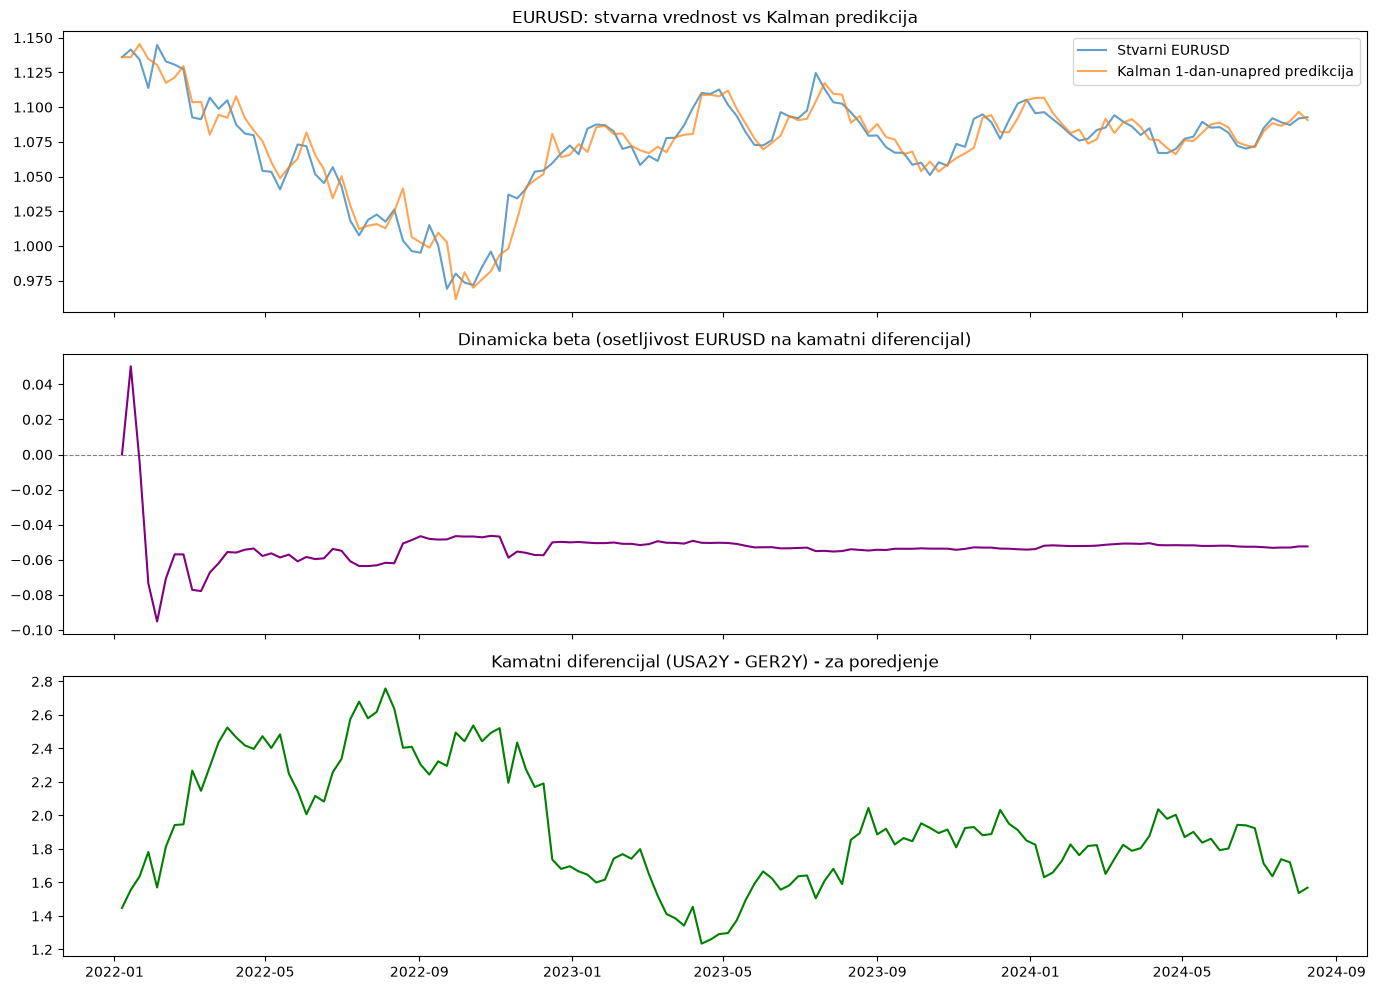

In [7]:
# 4. VIZUALIZACIJA - da li filter prati kurs razumno?
# ============================================================
 
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
 
axes[0].plot(df.index, df["EURUSD"], label="Stvarni EURUSD", alpha=0.7)
axes[0].plot(df.index, df["kalman_pred_tuned"], label="Kalman 1-dan-unapred predikcija", alpha=0.7)
axes[0].legend()
axes[0].set_title("EURUSD: stvarna vrednost vs Kalman predikcija")
 
axes[1].plot(df.index, df["kalman_beta"], color="purple")
axes[1].set_title("Dinamicka beta (osetljivost EURUSD na kamatni diferencijal)")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
 
axes[2].plot(df.index, df["rate_diff"], color="green")
axes[2].set_title("Kamatni diferencijal (USA2Y - GER2Y) - za poredjenje")
 
plt.tight_layout()
plt.show()